## COMP 6934 Winter 2026 In class Work 2

We're duplicating some of the charting ideas from note 2, but using a stored data set instead of generating data distributions with numpy.

The dataset is taken from <https://www.kaggle.com/datasets/jash312/canada-daily-weather-data-from-2018-to-2023>

That data set is sourced from environment canada's postings, but I am a little concerned some of the data rows has the M flags set and missing rainfall data. I'm wondering if the data was cleaned correctly. For now, I'm ignoring those data records and will let you know if I figure them out.

The original data also has some extended UTF characters in the column titles, namely the "degrees" symbol for temperature.  Some OS settings may not recognize or match searches on this symbol, so I have also included data files with this symbol removed. The original data sets have the word "combined" in the file names, and the cleaned up versions of the data files do not. Note if you want (or need) to use the cleaned-up data files, you will need to change the file names in the python script examples in this workbook. 

This problem set uses some additional matplotlib settings that are not shown in the previous tutorial in note 1 or note 2.

If the numpy library is not aleady installed, you may need to install it.

First, I grab the data from a csv format file into the familiar list-of-dictionaries format using a method from the standard csv python library:

In [73]:
from csv import DictReader

In [74]:
with open('jash312/NL_combined_weather_data.csv') as csvfile:
    reader = DictReader(csvfile)
    alldata = list(reader) # don't exceed your memory limits!
print(alldata[:5]) # first 5 data values

[{'Longitude (x)': '-53.99', 'Latitude (y)': '47.29', 'Station Name': 'ARGENTIA (AUT)', 'Climate ID': '8400104', 'Date/Time': '2022-07-22', 'Year': '2022', 'Month': '7', 'Day': '22', 'Data Quality': '', 'Max Temp (°C)': '', 'Max Temp Flag': 'M', 'Min Temp (°C)': '', 'Min Temp Flag': 'M', 'Mean Temp (°C)': '', 'Mean Temp Flag': 'M', 'Heat Deg Days (°C)': '', 'Heat Deg Days Flag': 'M', 'Cool Deg Days (°C)': '', 'Cool Deg Days Flag': 'M', 'Total Rain (mm)': '', 'Total Rain Flag': '', 'Total Snow (cm)': '', 'Total Snow Flag': '', 'Total Precip (mm)': '', 'Total Precip Flag': 'M', 'Snow on Grnd (cm)': '', 'Snow on Grnd Flag': '', 'Dir of Max Gust (10s deg)': '', 'Dir of Max Gust Flag': 'M', 'Spd of Max Gust (km/h)': '', 'Spd of Max Gust Flag': 'M'}, {'Longitude (x)': '-53.99', 'Latitude (y)': '47.29', 'Station Name': 'ARGENTIA (AUT)', 'Climate ID': '8400104', 'Date/Time': '2022-07-23', 'Year': '2022', 'Month': '7', 'Day': '23', 'Data Quality': '', 'Max Temp (°C)': '19.9', 'Max Temp Flag': '

In [75]:
alldata[0].keys()

dict_keys(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)', 'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)', 'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag', 'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)', 'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag', 'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)', 'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)', 'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag'])

In [76]:
len(alldata)

99657

That's too many data points for a standard plot. So I'll use the standard python filter method to futher reduce the list to observations taken at the St. John's Airport 

In [77]:
stja_data =  list(filter(lambda item: "ST. JOHN'S INTL A" in item['Station Name'] , alldata))
len(stja_data)

2191

That's still to many. Let's use Jan 2020 data:

In [78]:
j2020_data =  list(filter(lambda item: "2020" in item['Year'] and "1" == item["Month"], stja_data))
len(j2020_data)

31

In [79]:
j2020_data[0].keys()

dict_keys(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)', 'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)', 'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag', 'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)', 'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag', 'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)', 'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)', 'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag'])

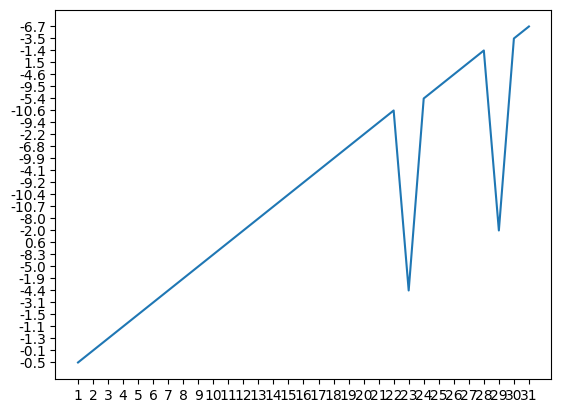

In [80]:
import matplotlib.pyplot as plt

days = [r['Day'] for r in j2020_data]
temp = [r['Mean Temp (°C)'] for r in j2020_data]
plt.plot(days,temp)
plt.show()

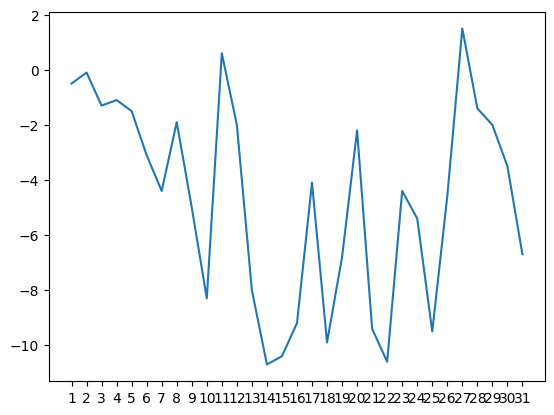

In [81]:
temp_nums = [float(r['Mean Temp (°C)']) for r in j2020_data]
plt.plot(days,temp_nums)
plt.show()

### Summary data

Selecting a range of data is pretty easy with list comprehensions, but reducing data by summarizing takes a little more work.

Let's sum and average some data for each month of 2020 from the St. John's Airport weather station.


In [82]:
avg_temp = [0]*12
tot_rain = [0]*12
days_count = [0]*12

def floatOrZ(val):
    try:
        return float(val)
    except ValueError:
        return 0.0
    
for rec in stja_data:
    if rec['Year'] != "2020": continue;
    tot_rain[int(rec['Month']) -1] += floatOrZ(rec['Total Precip (mm)'])
    avg_temp[int(rec['Month']) -1] += floatOrZ(rec['Mean Temp (°C)'])
    days_count[int(rec['Month']) -1] += 1

avg_temp = [temp/days for (temp,days) in zip(avg_temp,days_count)]

print(avg_temp,tot_rain,days_count)

[-4.7064516129032254, -4.1000000000000005, -2.9838709677419355, 1.2533333333333334, 6.645161290322581, 13.826666666666672, 13.558064516129031, 17.370967741935484, 14.256666666666668, 8.66451612903226, 3.3200000000000003, 2.0225806451612907] [134.79999999999998, 91.80000000000001, 139.4, 98.89999999999999, 96.0, 154.09999999999997, 180.4, 135.79999999999998, 100.10000000000001, 131.3, 130.89999999999998, 165.79999999999998] [31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]


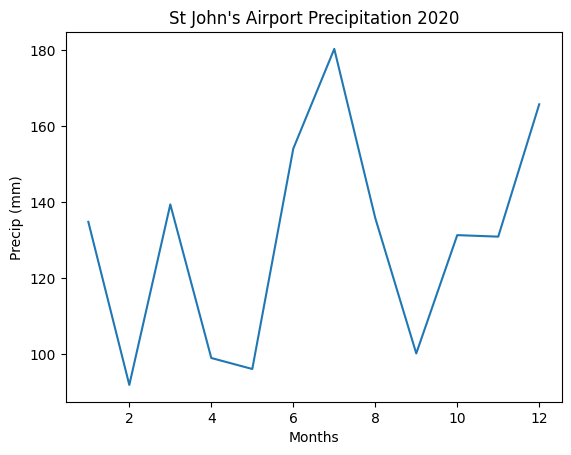

In [83]:
plt.plot(range(1,13), tot_rain)
plt.title("St John's Airport Precipitation 2020")
plt.xlabel('Months')
plt.ylabel('Precip (mm)')
plt.show()


## In-Class Problem Set #2





#### Problem 2.1

Read data for TORONTO CITY weather station from the ontario data file (ON_weather) and add a plot line for rainfall to the previous plot. Add new cell(s) below for this new plot. 

The notes do not show you how to add a legend for the two different lines, you can research and add this if you want an extra challenge.

In [84]:
with open('jash312/ON_weather.csv') as csvfile:
    reader = DictReader(csvfile)
    ondata = list(reader) # don't exceed your memory limits!
print(ondata[:5]) # first 5 data values

[{'Longitude (x)': '-82.43', 'Latitude (y)': '52.93', 'Station Name': 'ATTAWAPISKAT A', 'Climate ID': '6010400', 'Date/Time': '2018-01-01', 'Year': '2018', 'Month': '1', 'Day': '1', 'Data Quality': '', 'Max Temp (C)': '-18.8', 'Max Temp Flag': '', 'Min Temp (C)': '-34.4', 'Min Temp Flag': '', 'Mean Temp (C)': '-26.6', 'Mean Temp Flag': '', 'Heat Deg Days (C)': '44.6', 'Heat Deg Days Flag': '', 'Cool Deg Days (C)': '0.0', 'Cool Deg Days Flag': '', 'Total Rain (mm)': '', 'Total Rain Flag': 'M', 'Total Snow (cm)': '', 'Total Snow Flag': 'M', 'Total Precip (mm)': '0.0', 'Total Precip Flag': '', 'Snow on Grnd (cm)': '', 'Snow on Grnd Flag': '', 'Dir of Max Gust (10s deg)': '', 'Dir of Max Gust Flag': 'M', 'Spd of Max Gust (km/h)': '', 'Spd of Max Gust Flag': 'M'}, {'Longitude (x)': '-82.43', 'Latitude (y)': '52.93', 'Station Name': 'ATTAWAPISKAT A', 'Climate ID': '6010400', 'Date/Time': '2018-01-02', 'Year': '2018', 'Month': '1', 'Day': '2', 'Data Quality': '', 'Max Temp (C)': '-16.3', 'Max

In [85]:
ondata[0].keys()

dict_keys(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (C)', 'Max Temp Flag', 'Min Temp (C)', 'Min Temp Flag', 'Mean Temp (C)', 'Mean Temp Flag', 'Heat Deg Days (C)', 'Heat Deg Days Flag', 'Cool Deg Days (C)', 'Cool Deg Days Flag', 'Total Rain (mm)', 'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag', 'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)', 'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)', 'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag'])

In [86]:
len(ondata)

374429

In [87]:
list({item["Station Name"] for item in ondata})

['HAZELWOOD',
 'BEATRICE CLIMATE',
 'VINELAND',
 'ELORA RCS',
 'OSHAWA WPCP',
 'FORT SEVERN A',
 'LANSDOWNE HOUSE A',
 'BELLEVILLE',
 'HALIBURTON 3',
 'LITTLE FLATLAND ISLAND (AUT)',
 'SOUTHERN ONTARIO EMERGENCY PORTABLE WEATHER STATION',
 'PA KING CITY',
 'BARWICK',
 'SAULT STE MARIE A',
 'WESTERN ISLAND (AUT)',
 'AMHERSTBURG',
 'HAMILTON A',
 'POINT PETRE (AUT)',
 'ARMSTRONG (AUT)',
 'CHALK RIVER AECL',
 'SUDBURY CLIMATE',
 'RED LAKE A',
 'KINGSVILLE MOE',
 'GLEN ALLAN',
 'PEAWANUCK A',
 'SANDY LAKE A',
 'BIG TROUT LAKE A',
 'EGBERT CS',
 'SONYA SUNDANCE MEADOWS',
 'KEMPTVILLE CS',
 'SARNIA CLIMATE',
 'ST THOMAS WPCP',
 'COE HILL',
 'UPSALA (AUT)',
 'TORONTO NORTH YORK',
 'HARTINGTON IHD',
 'BALDWIN',
 'GORE BAY CLIMATE',
 'BIG TROUT LAKE',
 'ROYAL ISLAND (AUT)',
 'KIRKLAND LAKE CS',
 'POINT PELEE CS',
 'MUSKRAT DAM',
 'BANCROFT AUTO',
 'OMPAH-SEITZ',
 'NIPISSING',
 'GORE BAY-MANITOULIN',
 'BORDEN AWOS',
 'GODERICH',
 'TILLSONBURG WWTP',
 'PUKASKWA (AUT)',
 'BARRIE-ORO',
 'GEORGETOWN

In [88]:
# get data for toronto city
toc_data =  list(filter(lambda item:  'TORONTO CITY' in item['Station Name'] , ondata))
len(toc_data)

4382

In [89]:
j2020_data_toc =  list(filter(lambda item: "2020" in item['Year'] and "1" == item["Month"], toc_data))
len(j2020_data_toc)

62

In [90]:
j2020_data_toc[0].keys()

dict_keys(['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (C)', 'Max Temp Flag', 'Min Temp (C)', 'Min Temp Flag', 'Mean Temp (C)', 'Mean Temp Flag', 'Heat Deg Days (C)', 'Heat Deg Days Flag', 'Cool Deg Days (C)', 'Cool Deg Days Flag', 'Total Rain (mm)', 'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag', 'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)', 'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)', 'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag'])

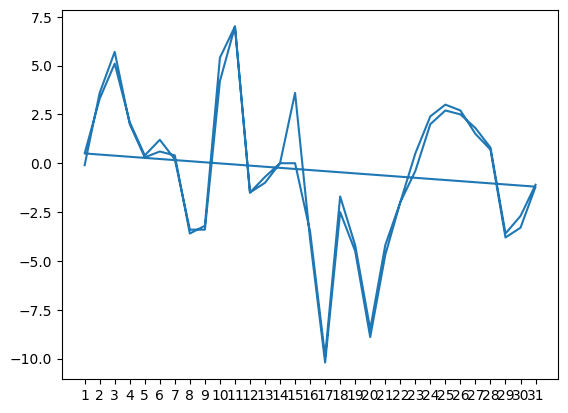

In [97]:
import matplotlib.pyplot as plt

days = [r['Day'] for r in j2020_data_toc]
temp = [float(r['Mean Temp (C)']) if r['Mean Temp (C)'] != "" else 0.0 for r in j2020_data_toc]
plt.plot(days,temp)
plt.show()

In [98]:
temp

[-0.1,
 3.6,
 5.7,
 2.0,
 0.3,
 0.6,
 0.4,
 -3.6,
 -3.2,
 5.4,
 7.0,
 -1.5,
 -1.0,
 0.0,
 3.6,
 -3.9,
 -10.2,
 -2.5,
 -4.5,
 -8.9,
 -4.7,
 -2.0,
 0.5,
 2.4,
 3.0,
 2.7,
 1.5,
 0.7,
 -3.8,
 -3.3,
 -1.2,
 0.5,
 3.3,
 5.1,
 2.1,
 0.4,
 1.2,
 0.2,
 -3.4,
 -3.4,
 4.2,
 7.0,
 -1.5,
 -0.7,
 0.0,
 0.0,
 -3.5,
 -9.9,
 -1.7,
 -4.2,
 -8.5,
 -4.2,
 -2.0,
 -0.4,
 2.0,
 2.7,
 2.5,
 1.8,
 0.8,
 -3.6,
 -2.7,
 -1.1]

ValueError: x and y must have same first dimension, but have shapes (62,) and (31,)

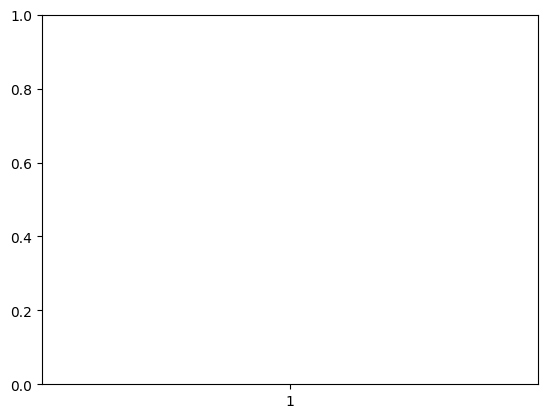

In [99]:
temp_nums = [float(r['Mean Temp (°C)']) for r in j2020_data]
plt.plot(days,temp_nums)
plt.show()

#### Problem 2.2

The notes show contruction of a scatter plot. Construct a scatter plot that shows temperature data across 12 months of 2020, (St. John's) and make the size of the circles proportional to the precipitation for the month. In other words, we are using actual data and not randomly genearted data.

#### Problem 2.3

Modify the scatter plot so that data points for negative temperatures are shown in blue and positive tempartures result in a red circle. Create a new cell for the new plot.

#### Problem 2.4

Some of the temperature data is missing (blank) in the data file. The existing summary code will include these as zero values when average the temperature, which is incorrect. This helps explain why the average temperature is showing so low in the summer months.

Fix the summary calculation by modifying the code to omit records with blank temperature values. Note that you will have to adjust the days_count as well in order to correct the average temperature calculation.

Create new cells to re-plot the results with the corrected summary data.